In [1]:
from pathlib import Path
import numpy as np

WINDOWED_DIR = Path(
    "/content/drive/MyDrive/processed_data/windowed"
)

saved_data = np.load(
    WINDOWED_DIR / "cleaned_windowed_gait_data.npz"
)

X_windows_cleaned = saved_data["X_windows"]
y_users = saved_data["y_users"]

SAMPLING_RATE = 100
TIME_STEPS = 500
NUMBER_OF_CHANNELS = 6

print("Cleaned sequence data loaded")
print("-" * 40)
print(f"Input shape: {X_windows_cleaned.shape}")
print(f"Labels shape: {y_users.shape}")
print(f"Number of users: {len(np.unique(y_users))}")
print(f"Missing values: {np.isnan(X_windows_cleaned).sum()}")

Cleaned sequence data loaded
----------------------------------------
Input shape: (1081, 500, 6)
Labels shape: (1081,)
Number of users: 10
Missing values: 0


In [5]:
# Define and inspect the LSTM
import tensorflow as tf

# Make results reproducible
np.random.seed(42)
tf.random.set_seed(42)


def build_lstm_model(
    time_steps,
    number_of_channels,
    number_of_classes
):
    """
    Build the LSTM for 10-class user identification.
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(time_steps, number_of_channels)
        ),

        tf.keras.layers.LSTM(
            6,
            return_sequences=False,
            name="lstm_layer"
        ),

        tf.keras.layers.Dense(
            number_of_classes,
            activation="softmax",
            name="output_layer"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


lstm_model = build_lstm_model(
    time_steps=TIME_STEPS,
    number_of_channels=NUMBER_OF_CHANNELS,
    number_of_classes=len(np.unique(y_users))
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 6)              │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            70 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 382 (1.49 KB)

 Trainable params: 382 (1.49 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train and Evaluate the LSTM
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Encode user labels
lstm_label_encoder = LabelEncoder()
y_lstm_encoded = lstm_label_encoder.fit_transform(y_users)

N_SPLITS = 5
EPOCHS = 40
BATCH_SIZE = 32

number_of_classes = len(np.unique(y_lstm_encoded))

cross_validator = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)


def scale_sequence_data(X_train, X_validation):
    """
    Standardize each of the six channels using only
    the training fold statistics.
    """

    channel_means = X_train.mean(
        axis=(0, 1),
        keepdims=True
    )

    channel_stds = X_train.std(
        axis=(0, 1),
        keepdims=True
    )

    # Prevent division by zero
    channel_stds = np.where(
        channel_stds == 0,
        1.0,
        channel_stds
    )

    X_train_scaled = (
        X_train - channel_means
    ) / channel_stds

    X_validation_scaled = (
        X_validation - channel_means
    ) / channel_stds

    return (
        X_train_scaled.astype(np.float32),
        X_validation_scaled.astype(np.float32)
    )


lstm_fold_metrics = []
lstm_training_histories = []

lstm_all_true_labels = []
lstm_all_predicted_labels = []

for fold_number, (train_indices, validation_indices) in enumerate(
    cross_validator.split(X_windows_cleaned, y_lstm_encoded),
    start=1
):
    print(f"Training LSTM fold {fold_number}/{N_SPLITS}...")

    X_train_raw = X_windows_cleaned[train_indices]
    X_validation_raw = X_windows_cleaned[validation_indices]

    y_train = y_lstm_encoded[train_indices]
    y_validation = y_lstm_encoded[validation_indices]

    # Scale channels using training-fold statistics only
    X_train_scaled, X_validation_scaled = (
        scale_sequence_data(
            X_train_raw,
            X_validation_raw
        )
    )

    # Build a new LSTM for this fold
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42 + fold_number)

    fold_model = build_lstm_model(
        time_steps=TIME_STEPS,
        number_of_channels=NUMBER_OF_CHANNELS,
        number_of_classes=number_of_classes
    )

    fold_history = fold_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_validation_scaled,
            y_validation
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    lstm_training_histories.append(
        fold_history.history
    )

    # Predict without model.predict() to reduce retracing warnings
    validation_probabilities = (
        fold_model(
            X_validation_scaled,
            training=False
        ).numpy()
    )

    validation_predictions = np.argmax(
        validation_probabilities,
        axis=1
    )

    lstm_all_true_labels.extend(y_validation)
    lstm_all_predicted_labels.extend(validation_predictions)

    fold_accuracy = accuracy_score(
        y_validation,
        validation_predictions
    )

    fold_precision = precision_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    fold_recall = recall_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    fold_f1 = f1_score(
        y_validation,
        validation_predictions,
        average="macro",
        zero_division=0
    )

    lstm_fold_metrics.append({
        "Fold": fold_number,
        "Accuracy": fold_accuracy,
        "Macro Precision": fold_precision,
        "Macro Recall": fold_recall,
        "Macro F1": fold_f1
    })

    print(
        f"  Accuracy: {fold_accuracy:.4f} | "
        f"Macro F1: {fold_f1:.4f}"
    )


# Convert collected predictions to arrays
lstm_all_true_labels = np.array(
    lstm_all_true_labels
)

lstm_all_predicted_labels = np.array(
    lstm_all_predicted_labels
)

lstm_fold_metrics_df = pd.DataFrame(
    lstm_fold_metrics
)

print("\nLSTM fold-level results:")
display(lstm_fold_metrics_df)

print("\nLSTM average cross-validation results:")
display(
    lstm_fold_metrics_df
    .drop(columns="Fold")
    .agg(["mean", "std"])
)

print("\nLSTM overall classification report:")
print(
    classification_report(
        lstm_all_true_labels,
        lstm_all_predicted_labels,
        labels=np.arange(number_of_classes),
        target_names=lstm_label_encoder.classes_,
        zero_division=0
    )
)

Training LSTM fold 1/5...
  Accuracy: 0.6912 | Macro F1: 0.6259
Training LSTM fold 2/5...
  Accuracy: 0.5694 | Macro F1: 0.5103
Training LSTM fold 3/5...
  Accuracy: 0.5880 | Macro F1: 0.4951
Training LSTM fold 4/5...
  Accuracy: 0.5972 | Macro F1: 0.5121
Training LSTM fold 5/5...
  Accuracy: 0.4815 | Macro F1: 0.3717

LSTM fold-level results:


,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,0.691244,0.613405,0.679165,0.625920
1,2,0.569444,0.553917,0.533622,0.510343
2,3,0.587963,0.562218,0.548722,0.495080
3,4,0.597222,0.532491,0.557844,0.512127
4,5,0.481481,0.405448,0.460048,0.371734



LSTM average cross-validation results:


,Accuracy,Macro Precision,Macro Recall,Macro F1
mean,0.585471,0.533496,0.555880,0.503041
std,0.074838,0.077500,0.078952,0.090194



LSTM overall classification report:
              precision    recall  f1-score   support

         112       0.45      0.48      0.46       101
          13       0.50      0.82      0.62       117
           2       0.60      0.88      0.72       136
          23       0.61      0.78      0.68       132
          24       0.55      0.61      0.58        90
          49       0.59      0.10      0.17       101
          52       0.45      0.38      0.41        95
          55       0.77      0.97      0.86       117
          70       0.64      0.26      0.37       108
          78       0.92      0.29      0.44        84

    accuracy                           0.59      1081
   macro avg       0.61      0.56      0.53      1081
weighted avg       0.61      0.59      0.55      1081



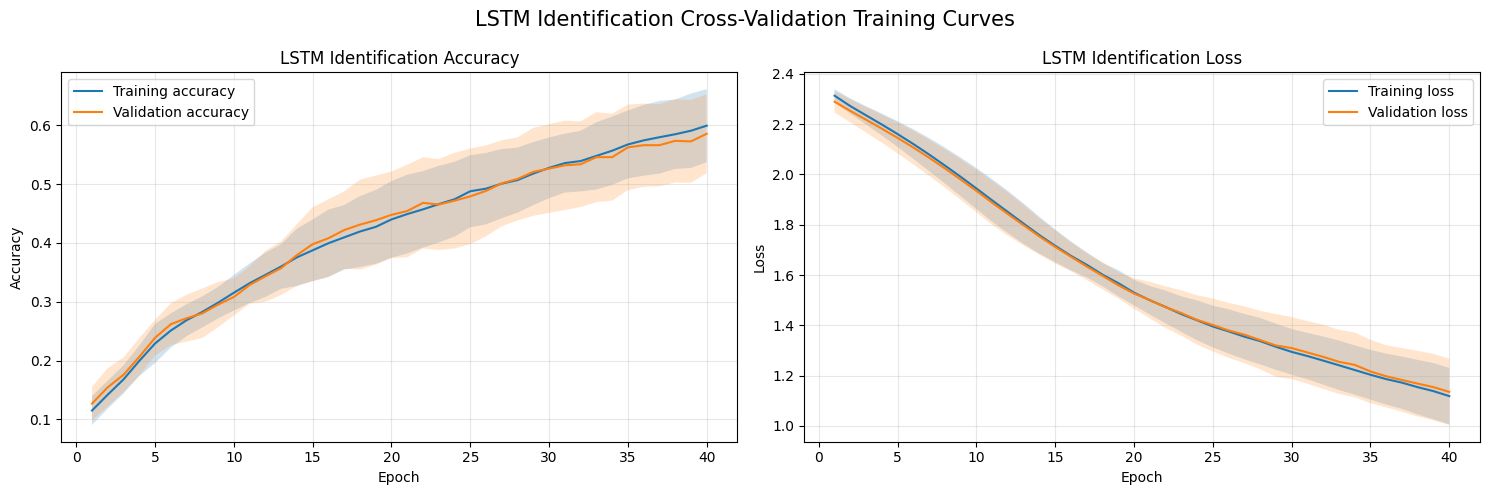

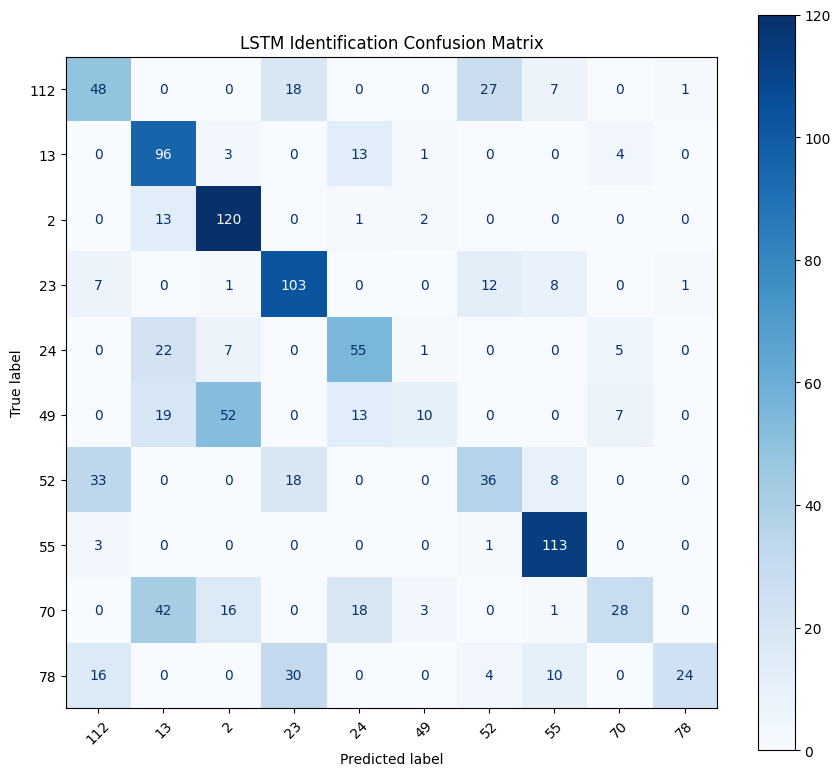

Saved LSTM plots to:
/content/drive/MyDrive/processed_data/plots


In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Convert histories into arrays
lstm_train_accuracy = np.array([
    history["accuracy"]
    for history in lstm_training_histories
])

lstm_validation_accuracy = np.array([
    history["val_accuracy"]
    for history in lstm_training_histories
])

lstm_train_loss = np.array([
    history["loss"]
    for history in lstm_training_histories
])

lstm_validation_loss = np.array([
    history["val_loss"]
    for history in lstm_training_histories
])

epochs = np.arange(
    1,
    lstm_train_accuracy.shape[1] + 1
)

# Calculate means and standard deviations
mean_lstm_train_accuracy = lstm_train_accuracy.mean(axis=0)
std_lstm_train_accuracy = lstm_train_accuracy.std(axis=0)

mean_lstm_validation_accuracy = (
    lstm_validation_accuracy.mean(axis=0)
)

std_lstm_validation_accuracy = (
    lstm_validation_accuracy.std(axis=0)
)

mean_lstm_train_loss = lstm_train_loss.mean(axis=0)
std_lstm_train_loss = lstm_train_loss.std(axis=0)

mean_lstm_validation_loss = (
    lstm_validation_loss.mean(axis=0)
)

std_lstm_validation_loss = (
    lstm_validation_loss.std(axis=0)
)


PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# Plot training and validation curves
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5)
)

# Accuracy
axes[0].plot(
    epochs,
    mean_lstm_train_accuracy,
    label="Training accuracy"
)

axes[0].fill_between(
    epochs,
    mean_lstm_train_accuracy - std_lstm_train_accuracy,
    mean_lstm_train_accuracy + std_lstm_train_accuracy,
    alpha=0.2
)

axes[0].plot(
    epochs,
    mean_lstm_validation_accuracy,
    label="Validation accuracy"
)

axes[0].fill_between(
    epochs,
    mean_lstm_validation_accuracy - std_lstm_validation_accuracy,
    mean_lstm_validation_accuracy + std_lstm_validation_accuracy,
    alpha=0.2
)

axes[0].set_title("LSTM Identification Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Loss
axes[1].plot(
    epochs,
    mean_lstm_train_loss,
    label="Training loss"
)

axes[1].fill_between(
    epochs,
    mean_lstm_train_loss - std_lstm_train_loss,
    mean_lstm_train_loss + std_lstm_train_loss,
    alpha=0.2
)

axes[1].plot(
    epochs,
    mean_lstm_validation_loss,
    label="Validation loss"
)

axes[1].fill_between(
    epochs,
    mean_lstm_validation_loss - std_lstm_validation_loss,
    mean_lstm_validation_loss + std_lstm_validation_loss,
    alpha=0.2
)

axes[1].set_title("LSTM Identification Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    "LSTM Identification Cross-Validation Training Curves",
    fontsize=15
)

plt.tight_layout()

lstm_curves_path = (
    PLOTS_DIR / "lstm_identification_training_curves.png"
)

plt.savefig(
    lstm_curves_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Create the LSTM confusion matrix
lstm_confusion_matrix_values = confusion_matrix(
    lstm_all_true_labels,
    lstm_all_predicted_labels,
    labels=np.arange(number_of_classes)
)

fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay(
    confusion_matrix=lstm_confusion_matrix_values,
    display_labels=lstm_label_encoder.classes_
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

ax.set_title("LSTM Identification Confusion Matrix")

plt.tight_layout()

lstm_confusion_path = (
    PLOTS_DIR / "lstm_identification_confusion_matrix.png"
)

plt.savefig(
    lstm_confusion_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved LSTM plots to:")
print(PLOTS_DIR)

In [9]:
# Save the LSTM results
RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save fold-level metrics
lstm_fold_metrics_df.to_csv(
    RESULTS_DIR / "lstm_identification_fold_metrics.csv",
    index=False
)

# Save classification report
lstm_classification_report_dict = classification_report(
    lstm_all_true_labels,
    lstm_all_predicted_labels,
    labels=np.arange(number_of_classes),
    target_names=lstm_label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

lstm_classification_report_df = pd.DataFrame(
    lstm_classification_report_dict
).transpose()

lstm_classification_report_df.to_csv(
    RESULTS_DIR / "lstm_identification_classification_report.csv"
)

# Save confusion matrix
lstm_confusion_matrix_df = pd.DataFrame(
    lstm_confusion_matrix_values,
    index=lstm_label_encoder.classes_,
    columns=lstm_label_encoder.classes_
)

lstm_confusion_matrix_df.to_csv(
    RESULTS_DIR / "lstm_identification_confusion_matrix.csv"
)

print("LSTM identification results saved to:")
print(RESULTS_DIR)

LSTM identification results saved to:
/content/drive/MyDrive/processed_data/results
